In [1]:
import funky.snanawrap as f
import funky.nreblocks as nb
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import pytorch_lightning as pl
import corner
import pandas as pd
import emcee
import pickle
rng=np.random.default_rng(seed=1)

In [2]:
with open("/home/ubuntu/SNANA/nre/nreSims.pickle", 'rb') as pikel: sims = pickle.load(pikel)
N = 5500  # select number of TRAINING sims
N_val = 700
N_lc = 100  # lc per sim (maximum possible over all sims)  ### smoothing gives 100 points

theta = np.empty((N, 2))
mu = np.empty((N, N_lc))
zhd = np.empty((N, N_lc))
for i in range(N):
    theta[i] = (sims[i].get('omega'), sims[i].get('w'))
    zhd[i], mu[i] = f.smoother(sims[i].get('zhd'), sims[i].get('mu'))

# validation
theta_val = np.empty((N_val, 2))
mu_val = np.empty((N_val, N_lc))
zhd_val = np.empty((N_val, N_lc))
for i, j in enumerate(range(N, N + N_val)):
    theta_val[i] = (sims[j].get('omega'), sims[j].get('w'))
    zhd_val[i], mu_val[i] = f.smoother(sims[j].get('zhd'), sims[j].get('mu'))

/tmp/ipykernel_39671/563579958.py:1: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  with open("/home/ubuntu/SNANA/nre/nreSims.pickle", 'rb') as pikel: sims = pickle.load(pikel)


In [ ]:
# standardise
theta_mean, theta_std = theta.mean(axis=0), theta.std(axis=0)
mu_mean, mu_std = mu.mean(axis=0), mu.std(axis=0)

mu = torch.tensor((mu - mu_mean) / mu_std).float()
theta = torch.tensor((theta - theta_mean) / theta_std).float()
x = mu

mu_val = torch.tensor((mu_val - mu_mean) / mu_std).float()
theta_val = torch.tensor((theta_val - theta_mean) / theta_std).float()
x_val = mu_val  # I don't want z anymore
# save means and stds, we need them to standardise the test
np.savez("/home/ubuntu/SNANA/nre/gioTesting/meansNstdsSummarisedNoZ.npz", theta_mean=theta_mean, theta_std=theta_std, mu_mean=mu_mean, mu_std=mu_std)#, zhd_mean=zhd_mean, zhd_std=zhd_std)

# Evaluate loss; initially it should be around -log(0.5) = 0.693
nre = nb.NeuralRatioEstimator(x_dim=100, theta_dim=2, hidden_dim=1020, layers=5)  # I don't want z anymore
batch_size = 100

dataset_train, dataset_val = TensorDataset(x, theta), TensorDataset(x_val, theta_val)

train_loader = DataLoader(dataset_train, batch_size=batch_size, num_workers=3, pin_memory=True, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=batch_size, num_workers=3, pin_memory=True, shuffle=False)

early_stop_callback = pl.callbacks.EarlyStopping(
    monitor="val_loss",  # Ensure your model logs this metric (e.g., self.log('val_loss', loss))
    patience=10,          # Number of validation checks with no improvement before stopping
    mode="min"           # 'min' for loss, 'max' for metrics like accuracy
)


checkpoint_callback = pl.callbacks.ModelCheckpoint( 
    every_n_epochs=10,
    save_top_k=-1      
)
logger = pl.loggers.CSVLogger('nreTestLogs', name="summariesNoZ")
trainer = pl.Trainer(max_epochs=250, logger=logger, callbacks=[early_stop_callback, checkpoint_callback])
nre.train()
trainer.fit(model=nre, train_dataloaders=train_loader, val_dataloaders=val_loader)

/tmp/ipykernel_20344/1769647157.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mu = torch.tensor((mu - mu_mean) / mu_std).float()
/tmp/ipykernel_20344/1769647157.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor((theta - theta_mean) / theta_std).float()
/tmp/ipykernel_20344/1769647157.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mu_val = torch.tensor((mu_val - mu_mean) / mu_std).float()
/tmp/ipykernel_20344/1769647157.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTen

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/ubuntu/miniconda3/envs/abc-torch/lib/python3.14/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/ubuntu/miniconda3/envs/abc-torch/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

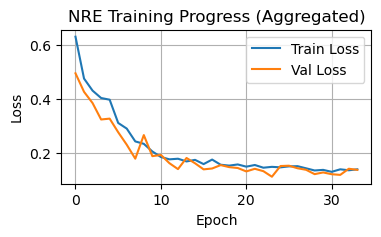

In [4]:
metrics = pd.read_csv(f"nreTestLogs/summariesNoZ/FINAL_VERSION/metrics.csv")

# Aggregate by epoch to remove NaNs
# This takes the non-NaN value for each epoch
epoch_metrics = metrics.groupby('epoch').max()

plt.figure(figsize=(4, 2))


# Plot from the aggregated dataframe
if 'train_loss' in epoch_metrics.columns:
    plt.plot(epoch_metrics.index, epoch_metrics['train_loss'], label='Train Loss')


if 'val_loss' in epoch_metrics.columns:
    plt.plot(epoch_metrics.index, epoch_metrics['val_loss'], label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()
plt.title('NRE Training Progress (Aggregated)')
plt.show()

In [5]:
npLoad = np.load("/home/ubuntu/SNANA/nre/gioTesting/meansNstdsSummarisedNoZ.npz")
theta_mean = npLoad["theta_mean"]
theta_std = npLoad["theta_std"]
mu_mean = npLoad["mu_mean"]
mu_std = npLoad["mu_std"]
zhd_mean = None
zhd_std = None
npLoad.close()
nre = nb.NeuralRatioEstimator.load_from_checkpoint('nreTestLogs/summariesNoZ/FINAL_VERSION/checkpoints/epoch=29-step=1650.ckpt', x_dim=100, theta_dim=2, hidden_dim=1020, layers=5)
nre.eval()

NeuralRatioEstimator(
  (classifier): Sequential(
    (0): Linear(in_features=102, out_features=1020, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=1020, out_features=1020, bias=True)
    (3): GELU(approximate='none')
    (4): Dropout(p=0.45, inplace=False)
    (5): Linear(in_features=1020, out_features=1020, bias=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.45, inplace=False)
    (8): Linear(in_features=1020, out_features=1020, bias=True)
    (9): GELU(approximate='none')
    (10): Dropout(p=0.45, inplace=False)
    (11): Linear(in_features=1020, out_features=1020, bias=True)
    (12): GELU(approximate='none')
    (13): Dropout(p=0.45, inplace=False)
    (14): Linear(in_features=1020, out_features=1020, bias=True)
    (15): GELU(approximate='none')
    (16): Dropout(p=0.45, inplace=False)
    (17): Linear(in_features=1020, out_features=1, bias=True)
  )
)

In [ ]:
muReal, zReal = f.extract_mu_zhd_from_file('/home/ubuntu/SNANA/salt2mus/realdata/SALT2mu_realdata.FITRES')
zReal, muReal = f.smoother(zReal, muReal) ### smooth

ndim, nwalkers = 2, 32
sampler = emcee.EnsembleSampler(nwalkers, ndim, nb.log_post, args=(muReal, None, theta_mean, theta_std, mu_mean, mu_std, None, None, nre, False))  # Init

# pos = rng.standard_normal((nwalkers, ndim))  # should be np.random.randn equivalent # starting theta position
pos = rng.uniform((0, -3), (1, 0), size=(nwalkers, ndim))
sampler.run_mcmc(pos, 5000, progress=True)  # run
with open('nreTestLogs/summariesNoZ/FINAL_VERSION/sampler.pkl', 'wb') as file:
    pickle.dump(sampler, file)

100%|██████████| 5000/5000 [02:19<00:00, 35.86it/s]


State([[ 0.16224459 -0.73491128]
 [ 0.03624238 -0.78715028]
 [ 0.40435833 -1.23183155]
 [ 0.27197729 -1.27440795]
 [ 0.22862897 -1.05456152]
 [ 0.23563944 -1.03247336]
 [ 0.2718779  -1.14666141]
 [ 0.24930514 -0.94923627]
 [ 0.21934584 -1.11114537]
 [ 0.11919538 -1.0361383 ]
 [ 0.08659509 -0.90068417]
 [ 0.14504057 -0.62535463]
 [ 0.11418283 -0.70352701]
 [ 0.11527322 -0.99941828]
 [ 0.06679968 -0.73402665]
 [ 0.34423659 -0.93817017]
 [ 0.3366639  -1.22419975]
 [ 0.45367428 -1.18999418]
 [ 0.08606627 -0.84530596]
 [ 0.07703478 -0.98295784]
 [ 0.22612825 -0.99740751]
 [ 0.20552397 -0.77266114]
 [ 0.057142   -0.63322968]
 [ 0.20794666 -0.70817824]
 [ 0.36205552 -1.35075236]
 [ 0.3801538  -1.17533512]
 [ 0.00901399 -0.92128571]
 [ 0.11245472 -0.83018338]
 [ 0.31720136 -0.88606563]
 [ 0.19724142 -1.27141587]
 [ 0.25505085 -0.67268087]
 [ 0.10730491 -0.6587166 ]], log_prob=[ 2.56297994  2.3919189   1.71306896  1.80249357  2.73649526  2.79398847
  2.56886172  2.83026266  2.53936458  2.283090

Autocorrelation time: [32.72893514 35.32657308]


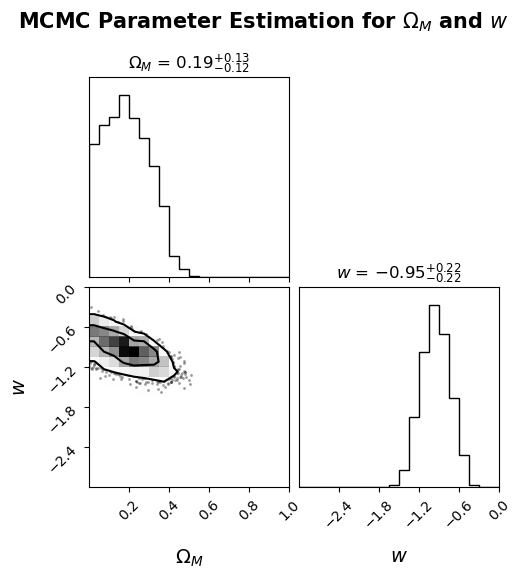

In [7]:
with open('nreTestLogs/summariesNoZ/FINAL_VERSION/sampler.pkl', 'rb') as file:
    sampler = pickle.load(file)
print("Autocorrelation time:", sampler.get_autocorr_time(discard=1000))
flat_samples = sampler.get_chain(discard=1000, thin=50, flat=True)  # get chain, look for what's flat
fig = corner.corner(
    flat_samples, 
    range=[(0, 1), (-3, 0)], 
    labels=[r"$\Omega_M$", r"$w$"],
    #quantiles=[0.16, 0.5, 0.84],      
    show_titles=True,                 
    title_kwargs={"fontsize": 12},    
    label_kwargs={"fontsize": 14},    
    color="black",                 
    hist_kwargs={"linewidth": 1},   
    hist_bin_factor=1,
    levels=(0.68,0.95),          
    fill_contours=False,               
    plot_datapoints=True,            
    data_kwargs={"alpha": 0.4}#, "marker": "o", "markersize": 2} 
)
fig.suptitle("MCMC Parameter Estimation for $\\Omega_M$ and $w$", fontsize=15, fontweight="bold", y=1.05)
plt.show()

# Useless testing

In [33]:
defeatParam = [.4, -3]
despairParam = [.4, -2.3]
mu4, z4 = f.sim_wrapper(defeatParam, 'defeat')
mu2, z2 = f.sim_wrapper(despairParam, 'despair')
# z_sim,mu_sim=(f.smoother(zhd,mu))

Removed /home/ubuntu/SNANA/SNROOT/SIM/defeat/defeat_SN000092.DAT bc no obs that t1 - t0 < 0.
Removed /home/ubuntu/SNANA/SNROOT/SIM/defeat/defeat_SN000083.DAT bc no obs that t1 - t0 < 0.
Removed /home/ubuntu/SNANA/SNROOT/SIM/defeat/defeat_SN000064.DAT bc no obs that t1 - t0 < 0.
Removed /home/ubuntu/SNANA/SNROOT/SIM/despair/despair_SN000066.DAT bc no obs that t1 - t0 < 0.
Removed /home/ubuntu/SNANA/SNROOT/SIM/despair/despair_SN000085.DAT bc no obs that t1 - t0 < 0.
Removed /home/ubuntu/SNANA/SNROOT/SIM/despair/despair_SN000096.DAT bc no obs that t1 - t0 < 0.


In [34]:
# smZreal, smMreal = f.smoother(zReal, muReal)
sz4, smu4 = f.smoother(z4, mu4)
sz2, smu2 = f.smoother(z2, mu2)

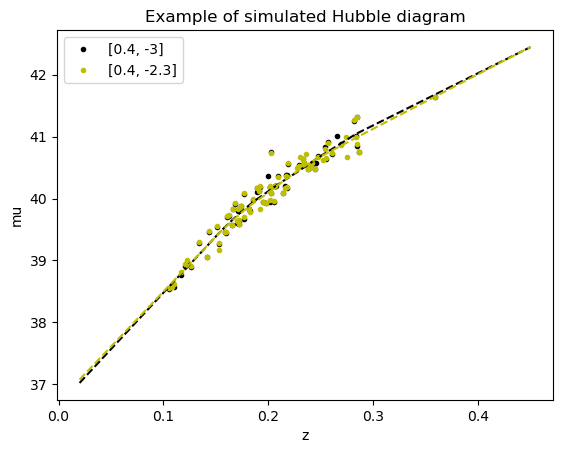

In [35]:
# plt.plot(zReal, muReal, '.r', label='real')
plt.plot(z4,mu4, '.k', label=str(defeatParam))
plt.plot(z2, mu2, '.y', label=str(despairParam))
# plt.plot(smZreal, smMreal, 'r', ls='--')
plt.plot(sz4, smu4, 'k', ls='--')
plt.plot(sz2, smu2, 'y', ls='--')
plt.title('Example of simulated Hubble diagram')
plt.legend()
plt.xlabel('z')
plt.ylabel('mu')
plt.show()

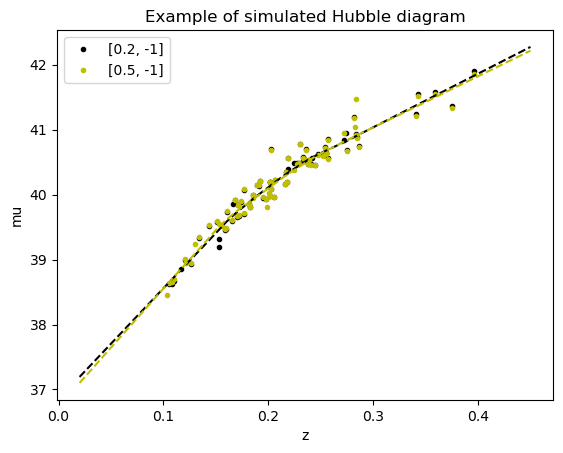

In [32]:
# plt.plot(zReal, muReal, '.r', label='real')
plt.plot(z4,mu4, '.k', label=str(defeatParam))
plt.plot(z2, mu2, '.y', label=str(despairParam))
# plt.plot(smZreal, smMreal, 'r', ls='--')
plt.plot(sz4, smu4, 'k', ls='--')
plt.plot(sz2, smu2, 'y', ls='--')
plt.title('Example of simulated Hubble diagram')
plt.legend()
plt.xlabel('z')
plt.ylabel('mu')
plt.show()

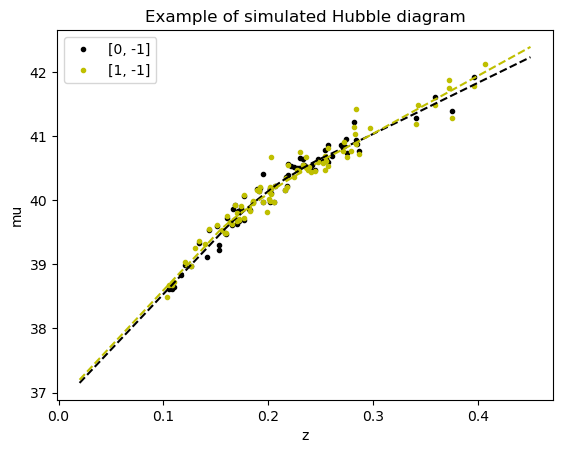

In [29]:
# plt.plot(zReal, muReal, '.r', label='real')
plt.plot(z4,mu4, '.k', label=str(defeatParam))
plt.plot(z2, mu2, '.y', label=str(despairParam))
# plt.plot(smZreal, smMreal, 'r', ls='--')
plt.plot(sz4, smu4, 'k', ls='--')
plt.plot(sz2, smu2, 'y', ls='--')
plt.title('Example of simulated Hubble diagram')
plt.legend()
plt.xlabel('z')
plt.ylabel('mu')
plt.show()